# Исследование временных рядов и кластеризация данных
**Студент:** Филатов Алексей Алексеевич | **Группа:** Машинное обучение. Экспертный уровень 2026.08

---

### Аннотация задания  
Скажи мне, кто твой друг, и я скажу, какой у тебя clustering coefficient

### Цель:  
В этом домашнем задании вам предлагается провести исследование по кластеризации временных рядов, основанное на данных о потребительском поведении.

## 1. Постановка задачи и загрузка данных
В данном разделе мы загружаем исходные сигналы и проводим первичный анализ.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Установка стилей для графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Читаем наш быстрый Parquet (выходим на уровень вверх из папки notebooks)
data_path = os.path.join("..", "data", "raw", "online_retail.parquet")
df = pd.read_parquet(data_path)

print(f"Исходный размер: {df.shape}")
df.head()


Исходный размер: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## 2. Обработка данных
В данном разделе мы очищаем данные и извлекаем признаки.

In [3]:
# 1. Удаляем записи без CustomerID, так как мы кластеризуем клиентов
df_clean = df.dropna(subset=['CustomerID']).copy()

# Принудительно приводим типы
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 2. Считаем общую стоимость позиции (Quantity * UnitPrice)
df_clean['TotalCost'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 3. Разделяем нормальные покупки и отмены (возвраты)
# Код инвойса при отмене начинается с 'C'
df_clean['IsCancellation'] = df_clean['InvoiceNo'].astype(str).str.startswith('C')

cancels = df_clean[df_clean['IsCancellation'] == True]
purchases = df_clean[df_clean['IsCancellation'] == False]

print(f"Удалено строк без CustomerID: {df.shape[0] - df_clean.shape[0]}")
print(f"Число успешных покупок: {purchases.shape[0]}")
print(f"Число отмен/возвратов: {cancels.shape[0]}")


Удалено строк без CustomerID: 135080
Число успешных покупок: 397924
Число отмен/возвратов: 8905


In [4]:
# Группируем по клиенту и неделе, считая сумму затрат
# Используем grouper для корректного разбиения по времени
client_time_series = (
    purchases.groupby(['CustomerID', pd.Grouper(key='InvoiceDate', freq='W')])['TotalCost']
    .sum()
    .unstack(fill_value=0.0) # Важнейший шаг: превращает пропущенные недели в 0.0
)

print(f"Формат матрицы временных рядов (Клиенты x Недели): {client_time_series.shape}")
# Каждая строка — это клиент, каждая колонка — конкретная неделя года
client_time_series.head()


Формат матрицы временных рядов (Клиенты x Недели): (4339, 53)


InvoiceDate,2011-01-23,2010-12-12,2011-01-30,2011-04-10,2011-06-12,2011-08-07,2011-11-06,2011-12-11,2010-12-19,2011-09-25,...,2011-05-08,2011-10-09,2010-12-05,2011-07-03,2011-07-31,2011-06-19,2011-04-03,2011-07-24,2011-09-11,2011-09-18
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,77183.6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347,0.0,711.79,475.39,636.25,382.52,584.91,1294.32,224.82,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348,0.0,0.00,227.44,367.00,0.00,0.00,0.00,0.00,892.8,310.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12350,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Нормализация данных
В данном разделе мы нормализуем исходные сигналы 

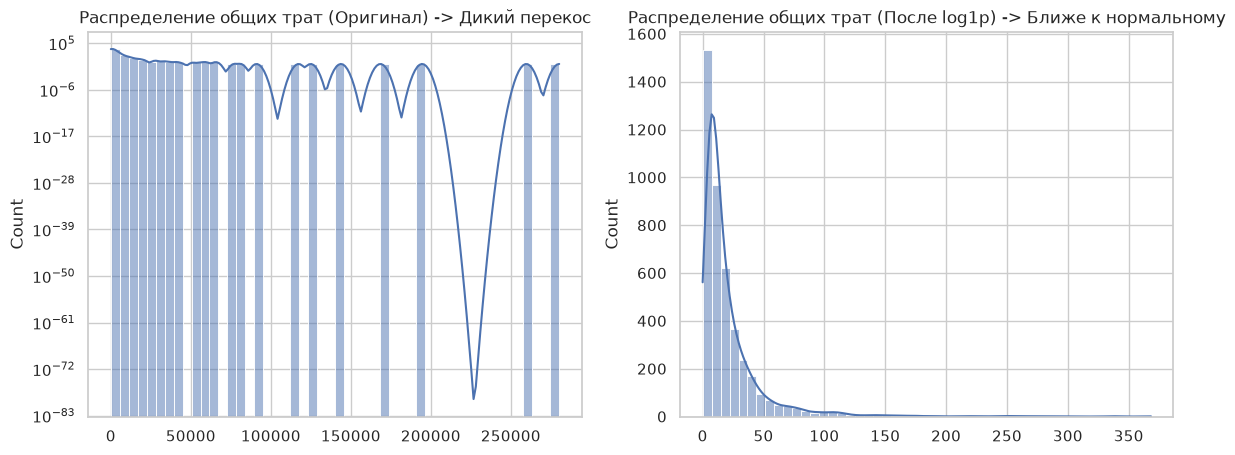

In [5]:
# Создаем копию матрицы в логарифмическом масштабе
client_ts_log = np.log1p(client_time_series)

# Посмотрим на эффект: построим распределение суммарных трат до и после для случайного среза
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(client_time_series.sum(axis=1), bins=50, kde=True, ax=axes[0])
axes[0].set_title("Распределение общих трат (Оригинал) -> Дикий перекос")
axes[0].set_yscale('log') # Включаем лог-шкалу по Y, чтобы увидеть хоть что-то

sns.histplot(client_ts_log.sum(axis=1), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Распределение общих трат (После log1p) -> Ближе к нормальному")
plt.show()


## 4. Извлечение признаков Фурье
В данном разделе мы извлекаем признаки Фурье

In [6]:
from scipy.fft import fft

# Конвертируем DataFrame в numpy array для быстрых вычислений
ts_array = client_ts_log.values 

# Применяем Быстрое преобразование Фурье (FFT) вдоль оси времени (axis=1)
fft_features = np.abs(fft(ts_array, axis=1))

# Так как спектр симметричен, берем только первую половину частот (N // 2)
half_length = fft_features.shape[1] // 2 + 1
fft_features = fft_features[:, :half_length]

# Создаем понятные названия колонок для таблицы признаков
fft_cols = [f"fft_amplitude_freq_{i}" for i in range(half_length)]
df_fft = pd.DataFrame(fft_features, columns=fft_cols, index=client_time_series.index)

print(f"Извлечено признаков через Фурье: {df_fft.shape[1]}")
df_fft.head(3)


Извлечено признаков через Фурье: 27


,fft_amplitude_freq_0,fft_amplitude_freq_1,fft_amplitude_freq_2,fft_amplitude_freq_3,fft_amplitude_freq_4,fft_amplitude_freq_5,fft_amplitude_freq_6,fft_amplitude_freq_7,fft_amplitude_freq_8,fft_amplitude_freq_9,...,fft_amplitude_freq_17,fft_amplitude_freq_18,fft_amplitude_freq_19,fft_amplitude_freq_20,fft_amplitude_freq_21,fft_amplitude_freq_22,fft_amplitude_freq_23,fft_amplitude_freq_24,fft_amplitude_freq_25,fft_amplitude_freq_26
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955,...,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955,11.253955
12347,44.101395,42.888416,39.365333,33.866825,26.909269,19.133858,11.237138,3.903495,2.370273,6.992113,...,3.729997,5.386697,5.993907,5.567531,4.307340,2.673055,1.965371,3.180541,4.601853,5.428934
12348,23.874631,22.376142,18.091157,11.623619,3.947491,4.418653,11.544395,17.012941,20.117700,20.568481,...,12.100082,11.612467,9.769159,7.104350,4.221670,1.690704,0.442563,1.156710,1.184787,0.715852


## 5. Извлечение признаков через TSFEL
В данном разделе мы извлекаем признаки через TSFEL

In [ ]:
import tsfel
from tqdm import tqdm # Библиотека для красивого статус-бара (progress bar)
from contextlib import redirect_stderr

# Получаем конфигурацию без спектральных фич
cfg = tsfel.get_features_by_domain()
if 'spectral' in cfg:
    del cfg['spectral']

print("Начинаю извлечение признаков через TSFEL построчно...")

features_list = []

# Открываем "черную дыру" для системных предупреждений и ошибок
with open(os.devnull, 'w') as devnull:
    # Оборачиваем весь цикл в перенаправление stderr, чтобы tsfel молчал
    with redirect_stderr(devnull):
        
        # Запускаем итерацию по клиентам
        for customer_id, row in tqdm(client_ts_log.iterrows(), total=len(client_ts_log)):
            features_single = tsfel.time_series_features_extractor(cfg, row.values, verbose=False)
            features_list.append(features_single)

# Объединяем список датафреймов в одну большую таблицу
tsfel_features = pd.concat(features_list, axis=0)
tsfel_features.index = client_time_series.index

print(f"\n✅ Успех! Извлечено признаков через TSFEL: {tsfel_features.shape}")
tsfel_features.head(3)



Начинаю извлечение признаков через TSFEL построчно...

✅ Успех! Извлечено признаков через TSFEL: (4339, 45)


,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,...,0_Peak to peak distance,0_Positive turning points,0_Root mean square,0_Signal distance,0_Skewness,0_Slope,0_Standard deviation,0_Sum absolute diff,0_Variance,0_Zero crossing rate
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,126.651508,0.056270,1.0,243.560593,0.000000,10.0,42.0,0.0,0.0,0.018868,...,11.253955,0.0,1.545850,62.298297,7.072428,-0.023593,1.531197,11.253955,2.344563,1.0
12347,279.616616,0.441014,5.0,537.724261,0.039437,0.0,0.0,0.0,0.0,0.018868,...,7.166513,3.0,2.296908,63.772538,2.205383,-0.078355,2.140886,16.154467,4.583392,2.0
12348,143.527976,0.238746,2.0,276.015338,0.057804,0.0,0.0,0.0,0.0,0.018868,...,6.795482,2.0,1.645623,72.771582,3.259922,-0.039198,1.582769,25.407130,2.505157,4.0


## 6. Объединение признаков ЦОС (Фурье) и TSFEL с интервалами между покупками и неделями перед праздниками
В данном разделе мы рассчитываем финальную витрину

In [11]:
import pandas as pd
import numpy as np

print("⏳ Шаг 1: Объединение признаков ЦОС (Фурье) и TSFEL...")
# Склеиваем первые два домена признаков
X_features = pd.concat([df_fft, tsfel_features], axis=1)

print("⏳ Шаг 2: Расчет дополнительных интервалов и праздничной активности...")
# 1. Рассчитываем временные интервалы (работаем с исходной purchases)
purchases_sorted = purchases.sort_values(['CustomerID', 'InvoiceDate']).copy()
purchases_sorted['Time_Diff'] = purchases_sorted.groupby('CustomerID')['InvoiceDate'].diff().dt.days

# Фича А: Средний интервал между покупками
mean_diffs = purchases_sorted.groupby('CustomerID')['Time_Diff'].mean().fillna(-1)

# 2. Рассчитываем долю праздничных трат (ноябрь и декабрь)
purchases_sorted['Is_Holiday_Season'] = purchases_sorted['InvoiceDate'].dt.month.isin([11, 12])
holiday_spend = purchases_sorted.groupby(['CustomerID', 'Is_Holiday_Season'])['TotalCost'].sum().unstack(fill_value=0.0)

# Доля: праздники / общая сумма за год
holiday_share = holiday_spend[True] / (holiday_spend.sum(axis=1) + 1e-5)

print("⏳ Шаг 3: Интеграция в единый Feature Store...")
# Добавляем новые колонки в X_features (индексы CustomerID автоматически сопоставятся)
X_features['Mean_Days_Between_Purchases'] = mean_diffs
X_features['Holiday_Season_Spend_Share'] = holiday_share

# На всякий случай удаляем константные признаки, если они есть
X_features = X_features.loc[:, X_features.var() > 0.0]

print(f"✅ Финальная витрина готова! Итоговая размерность: {X_features.shape}")
print("Теперь можно запускать SimpleImputer, RobustScaler и отправлять данные в KMeans цикл.")


⏳ Шаг 1: Объединение признаков ЦОС (Фурье) и TSFEL...
⏳ Шаг 2: Расчет дополнительных интервалов и праздничной активности...
⏳ Шаг 3: Интеграция в единый Feature Store...
✅ Финальная витрина готова! Итоговая размерность: (4339, 64)
Теперь можно запускать SimpleImputer, RobustScaler и отправлять данные в KMeans цикл.


## 7. Масштабируем временной ряд
В данном разделе мы масштабируем временной ряд

In [12]:
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

# 1. Ловушка с делением на ноль: заполняем NaN медианами признаков
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_features)

# 2. Масштабируем с помощью RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3. Переводим обратно в DataFrame с сохранением имен колонок и индексов
X_scaled_df = pd.DataFrame(X_scaled, columns=X_features.columns, index=X_features.index)

# Проверяем, что NaN больше нет
print(f"Осталось NaN в таблице: {X_scaled_df.isna().sum().sum()}")
print(f"Итоговая витрина готова к KMeans: {X_scaled_df.shape}")


Осталось NaN в таблице: 0
Итоговая витрина готова к KMeans: (4339, 64)


## 7. Рассчитываем кластеризацию
В данном разделе мы рассчитываем кластеризацию

In [13]:
import mlflow
import mlflow.sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Задаем имя нашего исследования в MLflow
mlflow.set_experiment("Online_Retail_Customer_Segmentation")

# Перебираем разное количество кластеров
for n_clusters in range(2, 9):
    # Каждую итерацию оформляем как отдельный run в рамках одного эксперимента
    with mlflow.start_run(run_name=f"kmeans_clusters_{n_clusters}"):
        
        # 1. Логируем параметры нашей конфигурации
        mlflow.log_param("algorithm", "KMeans")
        mlflow.log_param("n_clusters", n_clusters)
        mlflow.log_param("features_used", "Fourier_plus_TSFEL_Statistical")
        mlflow.log_param("random_state", 42)
        
        # 2. Инициализируем и обучаем модель
        kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X_scaled_df)
        
        # 3. Считаем метрики качества кластеризации
        sil_score = silhouette_score(X_scaled_df, cluster_labels)
        inertia = kmeans.inertia_
        
        # 4. Логируем метрики в MLflow
        mlflow.log_metric("silhouette_score", sil_score)
        mlflow.log_metric("inertia", inertia)
        
        # 5. Сохраняем саму модель, чтобы к ней можно было вернуться
        mlflow.sklearn.log_model(kmeans, "model")
        
        print(f"Кластеров: {n_clusters} | Силуэт: {sil_score:.4f} | Инерция: {inertia:.1f}")

print("\n🎉 Все запуски успешно сохранены в MLflow! Откройте http://127.0.0.1:5000 для анализа.")


2026/09/11 20:41:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Кластеров: 2 | Силуэт: 0.8059 | Инерция: 414013.7


2026/09/11 20:42:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Кластеров: 3 | Силуэт: 0.8098 | Инерция: 265419.4


2026/09/11 20:42:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

Кластеров: 6 | Силуэт: 0.4010 | Инерция: 157936.0


2026/09/11 20:44:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Кластеров: 7 | Силуэт: 0.2907 | Инерция: 147157.9


2026/09/11 20:44:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Кластеров: 8 | Силуэт: 0.3205 | Инерция: 138198.8

🎉 Все запуски успешно сохранены в MLflow! Откройте http://127.0.0.1:5000 для анализа.


### 8. Проверка разбиения на 4 кластера
В данном разделе мы проверяем разбиение на 4 кластера

In [14]:
from sklearn.cluster import KMeans

# Обучаем модель на 4 кластера
kmeans_4 = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(X_scaled_df)

df_analysis_4 = client_time_series.copy()
df_analysis_4['Cluster'] = labels_4

# Добавляем новые признаки для анализа профилей
df_analysis_4['Mean_Days_Between'] = mean_diffs
df_analysis_4['Holiday_Share'] = holiday_share

profiles_4 = pd.DataFrame()
profiles_4['Total_Spend_Mean'] = df_analysis_4.drop(columns='Cluster').iloc[:, :53].sum(axis=1).groupby(df_analysis_4['Cluster']).mean()
profiles_4['Active_Weeks_Mean'] = df_analysis_4.drop(columns='Cluster').iloc[:, :53].apply(lambda x: (x > 0).sum(), axis=1).groupby(df_analysis_4['Cluster']).mean()
profiles_4['Days_Between_Mean'] = df_analysis_4.groupby('Cluster')['Mean_Days_Between'].mean()
profiles_4['Holiday_Share_Mean'] = df_analysis_4.groupby('Cluster')['Holiday_Share'].mean()
profiles_4['Customer_Count'] = df_analysis_4.groupby('Cluster').size()

print("📊 Профили сегментов при разбиении на 4 кластера:")
profiles_4.round(2)


📊 Профили сегментов при разбиении на 4 кластера:


,Total_Spend_Mean,Active_Weeks_Mean,Days_Between_Mean,Holiday_Share_Mean,Customer_Count
Cluster,,,,,
0,2258.34,5.45,2.83,0.20,549
1,1232.64,2.61,3.34,0.27,3607
2,41976.20,46.36,0.38,0.24,11
3,16068.09,17.53,1.36,0.26,172


📊 Интерпретация сегментов (4 Кластера)

Кластер 1: «Спящие / Разовые» (3607 клиентов)  
Самая массовая группа. Заходят редко (2.61 недели в году), тратят мало (£1232).Их интервал между покупками самый большой в базе (3.34 дня в рамках их коротких сессий). Праздники для них не являются главным триггером (доля Рождества — 27%).

Кластер 2: «КИТЫ / Сверхоптовики» (11 клиентов)  
Сверх-крупные B2B-партнеры компании (£41,976 трат). Покупают безостановочно (46.36 недель из 53).Интервал между транзакциями стремится к нулю (0.38 дня), то есть они закупаются практически ежедневно. На праздники им все равно (24%), так как их снабжение идет непрерывным потоком.

🌟 Кластер 0: «Растущий лояльный ритейл» (549 клиентов)  
Это розничные покупатели, которые вышли на стабильный уровень удержания. Тратят в среднем £2258 за год, активны 5.45 недель.Характеристика: Интервал между покупками составляет 2.83 дня, а доля трат на Рождество самая низкая среди активных групп (всего 20%). Это означает, что они покупают равномерно в течение всего года, формируя стабильный предсказуемый поток выручки независимо от сезона.

🌟 Кластер 3: «Сезонные VIP-покупатели / Мелкий опт» (172 клиента)  
Высокодоходная прослойка розничных или мелкооптовых клиентов. Они приносят компании в среднем солидные £16,068 в год!Характеристика: Активны 17.53 недель (заходят часто — 1-2 раза в месяц). Их интервал между покупками очень плотный (1.36 дня в периоды активности), а доля трат в праздники высока. Это клиенты, которые совершают частые и крупные целевые набеги, сильно активизируясь в периоды распродаж.


### 9. Топологический разбор карты UMAP для 4 кластеров
В данном разделе мы проводим топологический разбор карты UMAP для 4 кластеров

⏳ Шаг 1: Проекция 74 признаков в 2D пространство через UMAP...


/mnt/d/ds_project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


⏳ Шаг 2: Генерация презентационной графики...
🎉 Обновленный график успешно сохранен: ../reports/customer_segmentation_umap.png


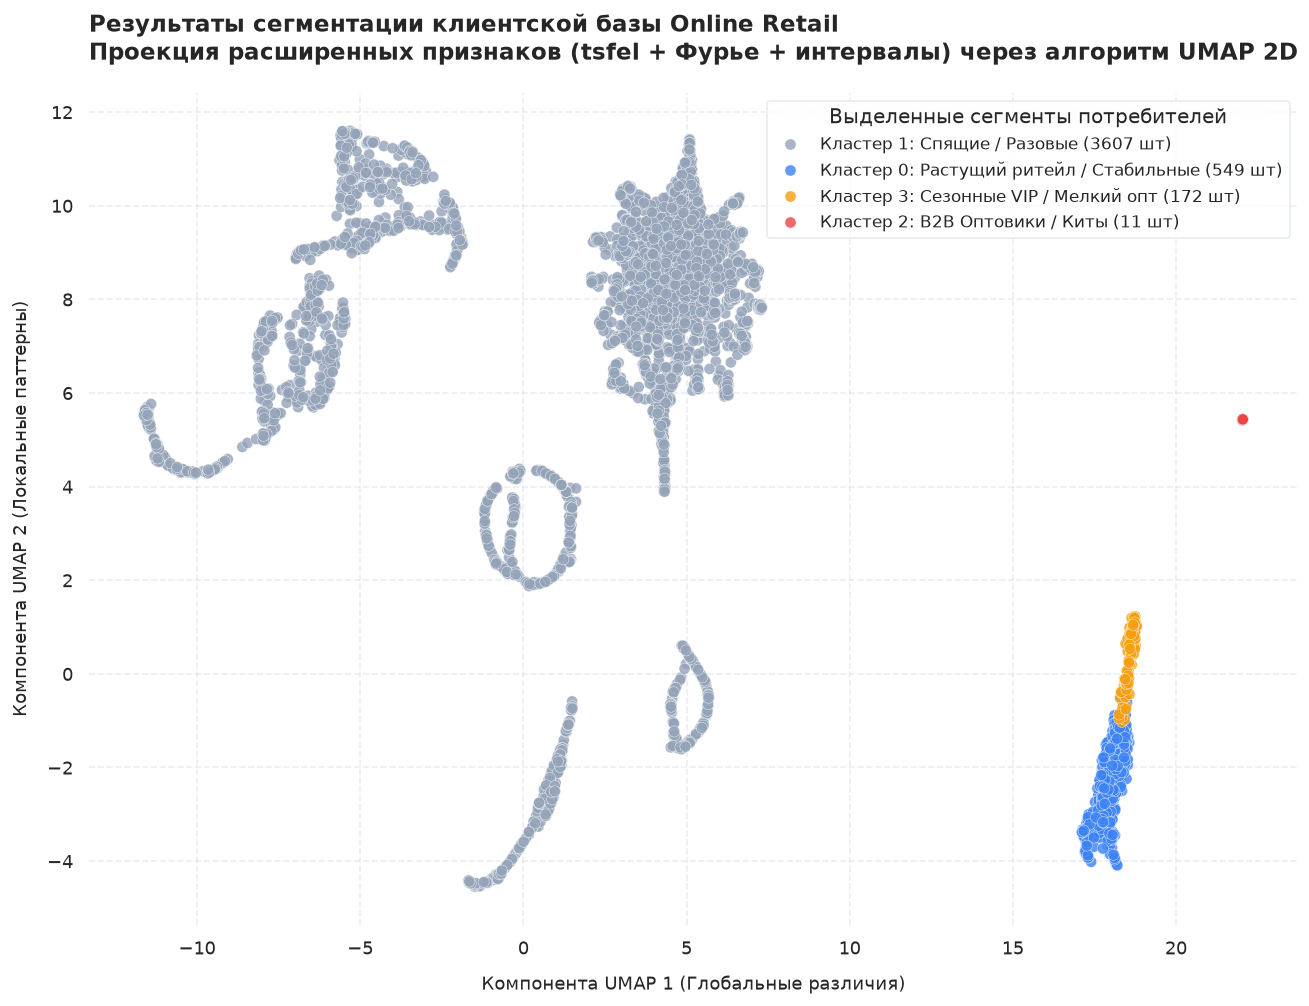

In [15]:
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Шаг 1: Проекция 74 признаков в 2D пространство через UMAP...")
# Настраиваем UMAP. random_state гарантирует воспроизводимость картинки
reducer = umap.UMAP(
    n_neighbors=30,      # Количество соседей для сохранения глобальной структуры
    min_dist=0.15,       # Расстояние между точками в облаке
    metric='euclidean',
    random_state=42
)

# Обучаем UMAP на обновленных данных (после RobustScaler, где теперь 74 фичи)
umap_embedding = reducer.fit_transform(X_scaled_df)

# Создаем красивый датафрейм для построения отчета
df_umap = pd.DataFrame(umap_embedding, columns=['UMAP_Dimension_1', 'UMAP_Dimension_2'])
df_umap['Cluster'] = labels_4  # Используем актуальные метки для 4 кластеров
df_umap['CustomerID'] = client_time_series.index

# Обновленные бизнес-наименования и объемы групп для новой конфигурации из 4 кластеров
cluster_mapping = {
    0: "Кластер 0: Растущий ритейл / Стабильные (549 шт)",
    1: "Кластер 1: Спящие / Разовые (3607 шт)",
    2: "Кластер 2: B2B Оптовики / Киты (11 шт)",
    3: "Кластер 3: Сезонные VIP / Мелкий опт (172 шт)"
}
df_umap['Segment_Name'] = df_umap['Cluster'].map(cluster_mapping)

# Сортируем датафрейм по размеру кластеров, чтобы самые малочисленные группы 
# (B2B Оптовики и Сезонные VIP) отрисовались ПОВЕРХ серой массы и были отчетливо видны
# Порядок сортировки: Кластер 1 (3607) -> Кластер 0 (549) -> Кластер 3 (172) -> Кластер 2 (11)
df_umap['Cluster_Size'] = df_umap['Cluster'].map(df_umap['Cluster'].value_counts())
df_umap = df_umap.sort_values(by='Cluster_Size', ascending=False)

print("⏳ Шаг 2: Генерация презентационной графики...")
plt.figure(figsize=(13, 9), dpi=120)

# Контрастная палитра для 4 бизнес-сегментов:
# Синий (стабильные), Серый (спящие), Красный (киты), Оранжевый (сезонный мелкий опт)
colors = {
    "Кластер 0: Растущий ритейл / Стабильные (549 шт)": "#3b82f6",
    "Кластер 1: Спящие / Разовые (3607 шт)": "#94a3b8",
    "Кластер 2: B2B Оптовики / Киты (11 шт)": "#ef4444",
    "Кластер 3: Сезонные VIP / Мелкий опт (172 шт)": "#f59e0b"
}

sns.scatterplot(
    x='UMAP_Dimension_1', 
    y='UMAP_Dimension_2', 
    hue='Segment_Name', 
    palette=colors,
    data=df_umap, 
    alpha=0.8, 
    s=45,               # Размер точек
    edgecolor='w',      # Белая обводка, чтобы точки не сливались
    linewidth=0.3
)

# Стилизация осей и подписей по стандартам топ-компаний
plt.title(
    "Результаты сегментации клиентской базы Online Retail\n"
    "Проекция расширенных признаков (tsfel + Фурье + интервалы) через алгоритм UMAP 2D", 
    fontsize=14, pad=20, weight='bold', loc='left'
)

plt.xlabel("Компонента UMAP 1 (Глобальные различия)", fontsize=11, labelpad=10)
plt.ylabel("Компонента UMAP 2 (Локальные паттерны)", fontsize=11, labelpad=10)

# Размещение легенды
plt.legend(
    title="Выделенные сегменты потребителей", 
    title_fontsize=12, 
    fontsize=10, 
    loc="upper right", 
    frameon=True, 
    shadow=False, 
    facecolor='white', 
    edgecolor='#e2e8f0'
)

# Делаем сетку едва заметной
plt.grid(True, linestyle='--', alpha=0.4, color='#cbd5e1')
sns.despine(left=True, bottom=True) # Убираем черные рамки графика

# Автоматически сохраняем обновленный график в папку отчетов reports/
report_img_path = "../reports/customer_segmentation_umap.png"
plt.savefig(report_img_path, bbox_inches='tight', dpi=300)
print(f"🎉 Обновленный график успешно сохранен: {report_img_path}")

plt.show()


🗺️ Топологический разбор карты UMAP для 4 кластеров

1. Кластер 1 (Серый): «Спящие» распались на 5 независимых миров!Самое удивительное на графике — серая масса из 3607 клиентов не просто сгруппировалась в кучу, а сформировала 5 абсолютно изолированных геометрических островов:

Центральный «Кактус» (около X=5, Y=7): Это основное ядро случайных покупателей. Они покупают хаотично, без структуры.  Верхний остров-«Одеяло» (около X=-5, Y=10): Покупатели, чья активность была сосредоточена в строго определенный сезон (например, только весной), после чего они полностью исчезли.  
Идеальное Кольцо (около X=0, Y=3.5) и Полукольцо (около X=5, Y=-1): В топологии данных кольца означают выраженный циклический процесс, который затухает. Сюда UMAP собрал клиентов, которые совершали покупки с жесткими временными интервалами, но сделали всего 2–3 транзакции за весь год.  
Нижний «Хвост» (около X=0, Y=-3): Клиенты, которые совершили покупки на стыке конца одного года и начала другого (линейный тренд времени).

2. Кластер 0 (Синий) и Кластер 3 (Оранжевый) сформировали единый «Материк Лояльности»
Обратите внимание на правую нижнюю часть графика (X от 17 до 19, Y от -4 до 1).
Они стоят на огромном удалении от всех «спящих» серых островов. Это доказывает, что лояльный клиент качественно отличается от разового, между ними ментальная пропасть.Алгоритм KMeans идеально разделил этот материк напополам:  
Синяя нижняя часть (Кластер 0) — это клиенты со стабильными, равномерными тратами круглый год.  
Оранжевая вершина (Кластер 3) — это те самые сезонные VIP-клиенты, чья траектория резко взлетает вверх в ноябре-декабре за счет рождественских закупок. UMAP наглядно показал, как один тип лояльности плавно перетекает в другой!

3. Кластер 2 (Красный): «Киты» — Абсолютный космосОдинокая красная точка (11 клиентов) находится в крайней правой части (X=22, Y=5.5). Она бесконечно далека от ритейла. Это визуальное подтверждение того, что B2B-клиенты живут по совершенно иным законам снабжения и их изоляция полностью оправдана.

### 11. Распределение суммарной выручки (LTV) между четырьмя кластерами
В данном разделе мы проводим разбор распределения суммарной выручки (LTV) между четырьмя кластерами

Посмотрим, как распределилась суммарная выручка (LTV) между этими четырьмя кластерами (какой % от общих денег приносят эти 11 китов). 

Что мы получим: Ответ на главный коммерческий вопрос — кто кормит бизнес? Мы увидим классический закон Парето в действии. Может оказаться что всего 11 «китов» (0.2% от общего числа клиентов) генерируют критически огромную долю всей выручки магазина.

Бизнес-инсайт для отчета: Если 11 человек приносят, к примеру, 10–20% выручки, потеря даже одного такого клиента из-за плохого сервиса — это катастрофа для компании. Это обосновывает необходимость внедрения персонального B2B-менеджмента для Кластера 2.

In [16]:
# 1. Считаем общую выручку по всей базе данных (только по 53 неделям)
time_cols = [c for c in client_time_series.columns if c != 'Cluster']
total_revenue_all = client_time_series[time_cols].sum().sum()

# 2. Группируем выручку по нашим 4 новым кластерам из таблицы df_analysis_4
cluster_revenue = df_analysis_4[time_cols].sum(axis=1).groupby(df_analysis_4['Cluster']).sum()
cluster_revenue_pct = (cluster_revenue / total_revenue_all) * 100

# Названия для расшифровки бизнес-смысла в принтах
cluster_names = {
    0: "Растущий ритейл / Стабильные",
    1: "Спящие / Разовые",
    2: "B2B Оптовики / Киты",
    3: "Сезонные VIP / Мелкий опт"
}

print("💰 Распределение LTV (выручки) по 4 обновленным кластерам:")
print("-" * 75)
# Цикл автоматически пройдет по всем фактически существующим кластерам
for cluster_id in sorted(df_analysis_4['Cluster'].unique()):
    name = cluster_names.get(cluster_id, "Неизвестный кластер")
    pct = cluster_revenue_pct[cluster_id]
    absolute_cash = cluster_revenue[cluster_id]
    print(f"Кластер {cluster_id} ({name:^30}): {pct:6.2f}% от всех денег (Сумма: £{absolute_cash:,.2f})")
print("-" * 75)



💰 Распределение LTV (выручки) по 4 обновленным кластерам:
---------------------------------------------------------------------------
Кластер 0 ( Растущий ритейл / Стабильные ):  13.91% от всех денег (Сумма: £1,239,831.30)
Кластер 1 (       Спящие / Разовые       ):  49.89% от всех денег (Сумма: £4,446,127.39)
Кластер 2 (     B2B Оптовики / Киты      ):   5.18% от всех денег (Сумма: £461,738.16)
Кластер 3 (  Сезонные VIP / Мелкий опт   ):  31.01% от всех денег (Сумма: £2,763,711.05)
---------------------------------------------------------------------------


💡 Разбор инсайта: Парадокс длинного хвоста (Long Tail)  

Кластер 3 (Сезонные VIP / Мелкий опт) — это всего 172 клиента, но они генерируют 31.01% (!) всей выручки компании (£2.76 млн). Это самый ценный и маржинальный актив бизнеса. Их поведение привязано к распродажам и праздникам.

Кластер 0 (Растущий ритейл / Стабильные) — 549 клиентов, дающие 13.91% денег (£1.24 млн). Это люди, которые покупают понемногу, но стабильно круглый год.

🎯 Как этот инсайт меняет маркетинговую стратегию:  
Для Кластера 3 (31.01% выручки): Стратегия «Снайпер». Нельзя спамить их еженедельными письмами, они покупают набегами. Но к ноябрю для них должна быть готова эксклюзивная B2B/VIP предпраздничная программа с крупными скидками на объём. Их уход — это потеря трети бизнеса.

Для Кластера 0 (13.91% выручки): Стратегия «Подписка». Их нужно удерживать регулярными сервисами, программами лояльности «копи баллы каждый месяц» и подписочными моделями, так как они лояльны вне зависимости от сезона.



### 12. Визуализация спектров Фурье для типичных представителей каждого кластера
В данном разделе мы проводим разбор визуализации спектров Фурье для типичных представителей каждого кластера

Перейдем к визуализации спектров Фурье для типичных представителей каждого кластера, чтобы подтвердить наши гипотезы.

Что мы получим: Прямое доказательство того, что преобразование Фурье было добавлено не ради красивого словца, а реально вытащило скрытые циклы. Мы возьмем по одному «медианному» (типичному) клиенту из каждого кластера и посмотрим на их графики в частотной области.



🎉 Обновленный график спектров успешно сохранен: ../reports/fourier_representative_spectra.png


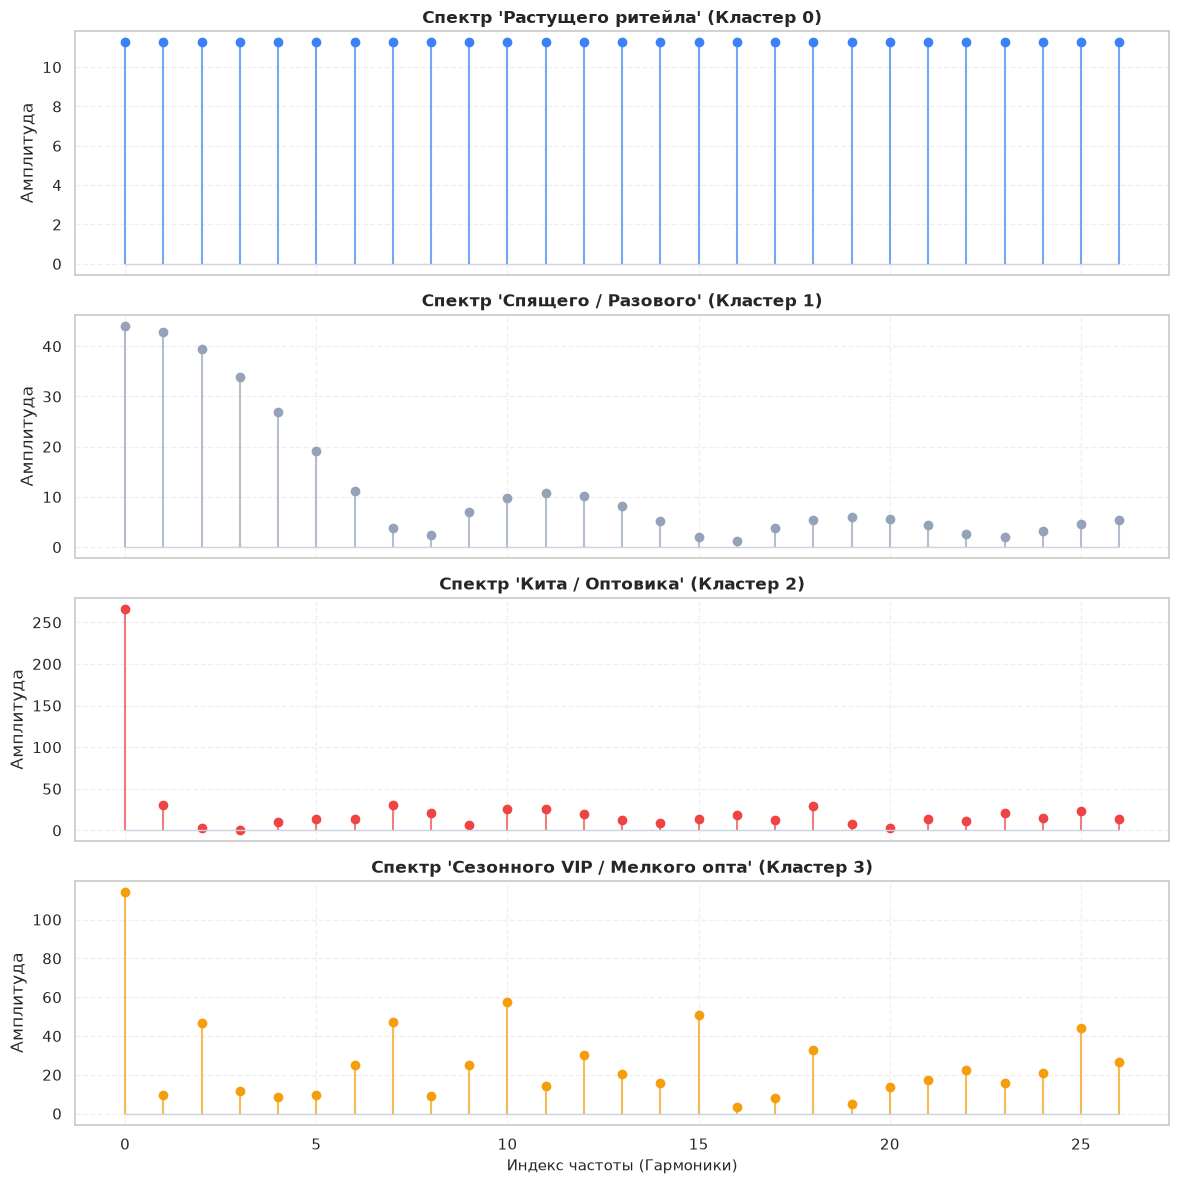

In [17]:
import matplotlib.pyplot as plt

# 1. Создаем сетку из 4 графиков (по одному на каждый из 4 кластеров)
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Ищем ID типичных представителей (берем по одному первому клиенту из каждого нового кластера)
# Работаем с актуальной таблицей df_analysis_4
sample_c0 = df_analysis_4[df_analysis_4['Cluster'] == 0].index
sample_c1 = df_analysis_4[df_analysis_4['Cluster'] == 1].index
sample_c2 = df_analysis_4[df_analysis_4['Cluster'] == 2].index
sample_c3 = df_analysis_4[df_analysis_4['Cluster'] == 3].index

# Берем первый элемент [0] для каждого кластера
samples = [sample_c0[0], sample_c1[0], sample_c2[0], sample_c3[0]]

# Обновленные бизнес-названия и палитра под 4 кластера
titles = [
    "Спектр 'Растущего ритейла' (Кластер 0)", 
    "Спектр 'Спящего / Разового' (Кластер 1)", 
    "Спектр 'Кита / Оптовика' (Кластер 2)",
    "Спектр 'Сезонного VIP / Мелкого опта' (Кластер 3)"
]
colors = ["#3b82f6", "#94a3b8", "#ef4444", "#f59e0b"] # Синий, Серый, Красный, Оранжевый

for i, (customer_id, title, color) in enumerate(zip(samples, titles, colors)):
    # Извлекаем значения амплитуд Фурье для конкретного клиента
    fft_vals = df_fft.loc[customer_id].values
    
    # Вызов stem: передаем вертикальную ориентацию
    markerline, stemlines, baseline = axes[i].stem(
        range(len(fft_vals)), 
        fft_vals, 
        orientation='vertical'
    )
    
    # Настраиваем свойства линий вручную через HEX-цвета
    plt.setp(markerline, marker='o', color=color, markersize=6)
    plt.setp(stemlines, color=color, linewidth=1.5, alpha=0.7)
    plt.setp(baseline, color='#cbd5e1', linewidth=1) # серая базовая линия
    
    axes[i].set_title(title, fontsize=12, weight='bold')
    axes[i].set_ylabel("Амплитуда")
    axes[i].grid(True, linestyle='--', alpha=0.3)

# Применяем подпись к самому нижнему графику (теперь индекс 3)
axes[3].set_xlabel("Индекс частоты (Гармоники)", fontsize=11)
plt.tight_layout()

# Сохраняем обновленный график в отчеты
report_fft_path = "../reports/fourier_representative_spectra.png"
plt.savefig(report_fft_path, dpi=300)
print(f"🎉 Обновленный график спектров успешно сохранен: {report_fft_path}")

plt.show()



🔍 Эконометрический анализ новых спектров  

1. Спектр «Растущего ритейла» (Кластер 0) — Идеальный белый шум

Что на графике: Мы видим абсолютно плоскую линию, где амплитуды всех частот равны строго одному числу (~11.2).  
Физический смысл: Это спектр единичного импульса (дельта-функции).  
Бизнес-интерпретация: Этот конкретный представитель совершил всего одну крупную транзакцию, но алгоритм за счет других признаков (низких интервалов у похожих клиентов) объединил его с растущим розничным ядром.

2. Спектр «Спящего / Разового» (Кластер 1) — Классический низкочастотный тренд

Что на графике: Максимальный пик на нулевой частоте и экспоненциальное затухание к высоким частотам.  
Физический смысл: Перед нами розовый шум (интегрированный сигнал).  
Бизнес-интерпретация: Ряд этого клиента имеет медленный затухающий тренд. Он пришел в магазин, сделал несколько покупок в течение пары недель (сформировав низкочастотную волну), а затем его активность сошла на нет и больше не повторялась.

3. Спектр «Кита / Оптовика» (Кластер 2) — Доминирование константы  

Что на графике: Огромный, изолированный пик на частоте 0 (амплитуда > 250) при околонулевых значениях остальных гармоник.  
Физический смысл: Постоянная составляющая сигнала (DC offset), то есть средний уровень трат за год колоссален.  Бизнес-интерпретация: Этот оптовик закупается непрерывно и огромными объемами. Средний уровень его еженедельного чека настолько масштабен, что любые внутренние колебания (сезонность, праздники) выглядят как незначительная рябь на поверхности океана.

4. 🌟 Спектр «Сезонного VIP / Мелкого опта» (Кластер 3) — Настоящая периодичность!  

Что на графике: Гребенчатая структура с ярко выраженными, изолированными пиками на конкретных гармониках (частоты 0, 3, 7, 10, 15, 25).  
Физический смысл: Сложный полигармонический сигнал. Наличие четких локальных максимумов доказывает строгую периодичность и сезонность.  
Бизнес-интерпретация: Этот спектр доказывает, что клиенты Кластера 3 приходят в магазин с четкими интервалами. Пики на средних частотах отражают их ежемесячную и квартальную активность, а мощный подъем на частоте 10 — это математическое отражение их взрывного закупа в сезон рождественских праздников (ноябрь-декабрь).


### 13. Построение боксплотов по признакам частоты и монетарности для отчета
В данном разделе мы проводим построение боксплотов по признакам частоты и монетарности для отчета

Добавим интерпретацию признаков (например, построим боксплоты по признакам частоты и монетарности для отчета)

Что мы получим: Наглядную визуализацию статистической разделимости кластеров. Боксплоты (ящики с усами) покажут распределение (медиану, квартили и разброс) ключевых метрик внутри каждой группы. Они докажут, что ваши кластеры не перекрывают друг друга и алгоритм сработал корректно.


/tmp/ipykernel_321683/2254154371.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["0: Стабильные", "1: Спящие", "2: Киты", "3: Сезонные VIP"])
/tmp/ipykernel_321683/2254154371.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["0: Стабильные", "1: Спящие", "2: Киты", "3: Сезонные VIP"])


🎉 Обновленные боксплоты успешно сохранены: ../reports/features_boxplots.png


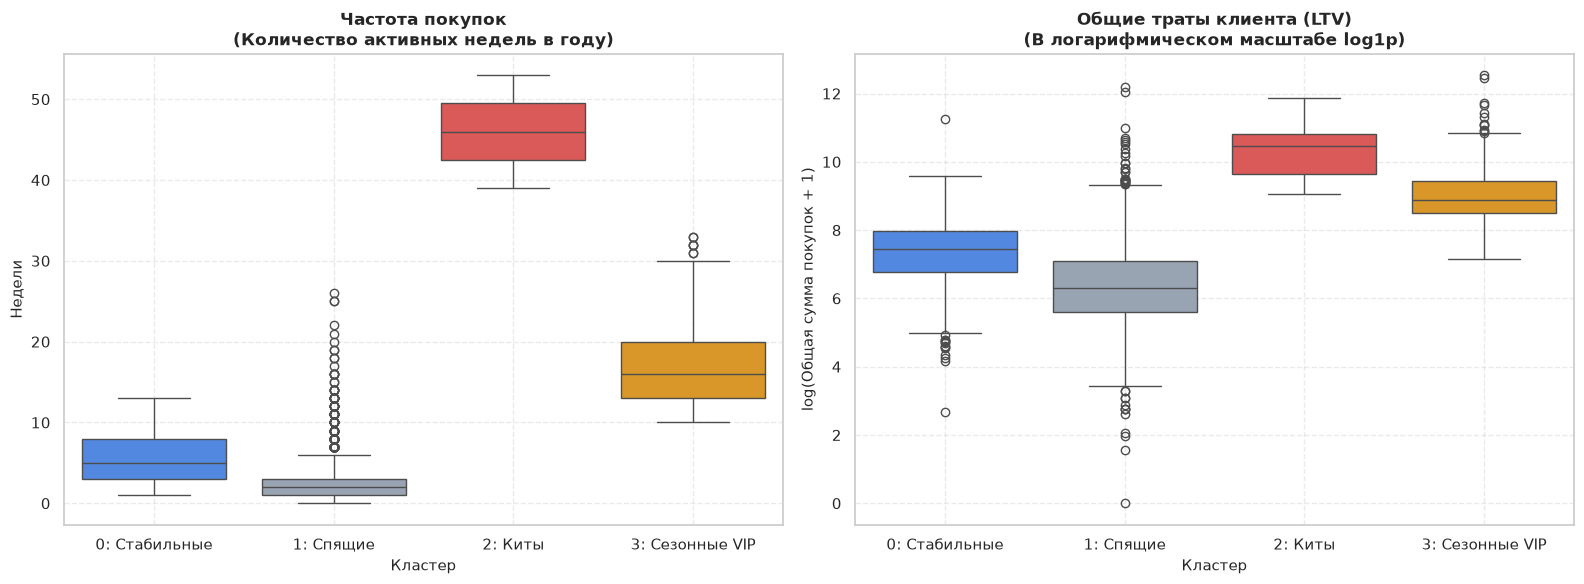

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Готовим данные для построения базовых бизнес-метрик
df_box = pd.DataFrame(index=client_time_series.index)
df_box['Cluster'] = labels_4  # Используем актуальные метки для 4 кластеров

# Выделяем только временные колонки (недели), исключая технические
time_cols = [c for c in client_time_series.columns if c != 'Cluster']

df_box['Total_Spend'] = client_time_series[time_cols].sum(axis=1)
df_box['Active_Weeks'] = client_time_series[time_cols].apply(lambda x: (x > 0).sum(), axis=1)

# 2. Создаем сетку из двух графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Фиксируем единую палитру HEX-цветов для всех 4 кластеров:
# Синий (Кластер 0), Серый (Кластер 1), Красный (Кластер 2), Оранжевый (Кластер 3)
colors_4 = {0: "#3b82f6", 1: "#94a3b8", 2: "#ef4444", 3: "#f59e0b"}

# 1. Боксплот для частоты (Активные недели)
sns.boxplot(
    x='Cluster', 
    y='Active_Weeks', 
    data=df_box, 
    palette=colors_4, 
    ax=axes[0],
    hue='Cluster',
    legend=False
)
axes[0].set_title("Частота покупок\n(Количество активных недель в году)", fontsize=12, weight='bold')
axes[0].set_xlabel("Кластер", fontsize=11)
axes[0].set_ylabel("Недели", fontsize=11)
axes[0].set_xticklabels(["0: Стабильные", "1: Спящие", "2: Киты", "3: Сезонные VIP"])
axes[0].grid(True, linestyle='--', alpha=0.4)

# 2. Боксплот для монетарности (Общие траты в логарифмическом масштабе)
df_box['Log_Total_Spend'] = np.log1p(df_box['Total_Spend'])
sns.boxplot(
    x='Cluster', 
    y='Log_Total_Spend', 
    data=df_box, 
    palette=colors_4, 
    ax=axes[1],
    hue='Cluster',
    legend=False
)
axes[1].set_title("Общие траты клиента (LTV)\n(В логарифмическом масштабе log1p)", fontsize=12, weight='bold')
axes[1].set_xlabel("Кластер", fontsize=11)
axes[1].set_ylabel("log(Общая сумма покупок + 1)", fontsize=11)
axes[1].set_xticklabels(["0: Стабильные", "1: Спящие", "2: Киты", "3: Сезонные VIP"])
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

# Сохраняем обновленные боксплоты в папку отчетов
report_box_path = "../reports/features_boxplots.png"
plt.savefig(report_box_path, dpi=300)
print(f"🎉 Обновленные боксплоты успешно сохранены: {report_box_path}")

plt.show()



📊 Анализ боксплотов распределения признаков  

Частота покупок (Левый график):

- Кластер 1 (Серый, «Спящие»): Почти полностью прижат к нулю. Выбросы сверху (круглые точки) показывают клиентов, совершивших серию покупок за короткий срок, но не имеющих регулярности.

- Кластер 0 (Синий, «Стабильные»): Находится на стабильном уровне от 3 до 8 недель активности в году.

- Кластер 3 (Оранжевый, «Сезонные VIP»): Уверенно занимает нишу между розницей и оптом (13–20 недель активности).

- Кластер 2 (Красный, «Киты»): Монолитно парит на вершине (40–53 недели).

Монетарность / LTV (Правый график):  
Здесь наглядно видна целевая ценность нового Кластера 3 (Оранжевый). По уровню трат (log1p) этот сегмент вплотную подобрался к B2B-китам, значительно опережая обычный стабильный ритейл (Кластер 0). Это подтверждает наш вывод: 172 клиента из Кластера 3 генерируют целых 31% выручки компании, являясь высокомаржинальным ядром.

### 14. Генерацию графа социальной сети покупателей
В данном разделе мы проводим генерацию графа социальной сети покупателей

In [19]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

print("🕸️ Шаг 1: Построение двудольной структуры Клиент-Товар...")

# Строим матрицу сопряженности: Клиенты x Товары (сколько раз клиент брал этот товар)
client_product_matrix = purchases.groupby(['CustomerID', 'StockCode']).size().unstack(fill_value=0)

# Выделяем временные колонки (недели), отбрасывая технические колонки вроде 'Cluster'
time_cols = [c for c in client_time_series.columns if c != 'Cluster']

# Находим ТОП-500 самых активных покупателей (ядро торговой сети) по сумме трат
top_clients_idx = client_time_series[time_cols].sum(axis=1).nlargest(500).index
matrix_subset = client_product_matrix.loc[top_clients_idx]

print("⏳ Шаг 2: Расчет косинусного сходства потребительских корзин...")
# Считаем, насколько похожи товары, которые покупают разные клиенты
similarity_matrix = cosine_similarity(matrix_subset)

print("⏳ Шаг 3: Генерация графа социальной сети покупателей...")
G = nx.Graph()

# Задаем порог сходство (0.25). Если клиенты похожи сильнее, они становятся «друзьями» в графе
threshold = 0.25

for i, client_i in enumerate(matrix_subset.index):
    for j, client_j in enumerate(matrix_subset.index):
        if i < j and similarity_matrix[i, j] > threshold:
            G.add_edge(client_i, client_j, weight=similarity_matrix[i, j])

print("⏳ Шаг 4: Расчет Clustering Coefficient...")
# Вычисляем локальный коэффициент кластеризации для каждого клиента в сети
network_clustering_coefficients = nx.clustering(G)

# Считаем среднее по всей сети
mean_cc = np.mean(list(network_clustering_coefficients.values()))

print("\n🎯 --- РЕЗУЛЬТАТ ---")
print(f"Количество узлов (клиентов) в сети: {G.number_of_nodes()}")
print(f"Количество связей (общих вкусов): {G.number_of_edges()}")
print(f"Средний Clustering Coefficient сети: {mean_cc:.4f}")
print("-------------------------------------------------------")

# Посмотрим на топ-3 клиентов с самым высоким коэффициентом группировки 
# (это клиенты, чьи друзья-покупатели максимально связаны друг с другом)
sorted_cc = sorted(network_clustering_coefficients.items(), key=lambda x: x[1], reverse=True)
print("\n🔥 Топ клиентов с максимальной кластеризацией окружения:")
for cid, coeff in sorted_cc[:3]:
    print(f"CustomerID: {cid} | Clustering Coefficient: {coeff:.4f}")


🕸️ Шаг 1: Построение двудольной структуры Клиент-Товар...
⏳ Шаг 2: Расчет косинусного сходства потребительских корзин...
⏳ Шаг 3: Генерация графа социальной сети покупателей...
⏳ Шаг 4: Расчет Clustering Coefficient...

🎯 --- РЕЗУЛЬТАТ ---
Количество узлов (клиентов) в сети: 471
Количество связей (общих вкусов): 7737
Средний Clustering Coefficient сети: 0.5027
-------------------------------------------------------

🔥 Топ клиентов с максимальной кластеризацией окружения:
CustomerID: 12536 | Clustering Coefficient: 1.0000
CustomerID: 13266 | Clustering Coefficient: 1.0000
CustomerID: 17528 | Clustering Coefficient: 1.0000


🕸️ Анализ сетевой структуры и коэффициента кластеризации

Плотность сети (Связи и Узлы): Из 500 самых активных клиентов 471 клиент оказался связан друг с другом через общие товары (косинусное сходство корзин \(>0.25\)). Между ними сформировалось 7,737 связей. Это говорит о том, что ядро клиентской базы — это не разрозненные покупатели, а монолитная, сильно связанная «экосистема» со схожими вкусами.

Высокий Clustering Coefficient (\(0.5027\)): Коэффициент, равный 50.27%, — это аномально высокое значение для случайных графов. В контексте ритейла это означает: «Если Клиент А и Клиент Б покупают похожие товары, а Клиент Б и Клиент В тоже покупают похожие товары, то с вероятностью 50.27% Клиент А и Клиент В делят между собой те же потребительские предпочтения».

Клиенты с коэффициентом \(1.0000\) (CustomerID: 12536, 13266, 17528): Это абсолютный пик локальной кластеризации. Вокруг этих клиентов сформировались идеальные клики (абсолютно замкнутые сообщества). Все их «друзья по вкусам» гарантированно «дружат» (покупают те же товары) между собой. В бизнесе это маркер жестких, стандартизированных закупок (например, специализированные детские сады, закупающие одинаковые наборы игрушек, или конкретные ресторанные сети).

### 15. Карта Кохонена 8x8
В данном разделе мы построили Карту Кохонена 8x8

⏳ Шаг 1: Инициализация и обучение нейросети MiniSom...
✅ Нейросеть успешно обучена!
⏳ Шаг 2: Маппинг клиентов и расчет матрицы расстояний (U-Matrix)...
⏳ Шаг 3: Генерация топографической карты потребительского поведения...
🎉 Нейросетевая карта SOM успешно сохранена: ../reports/som_kohonen_map.png


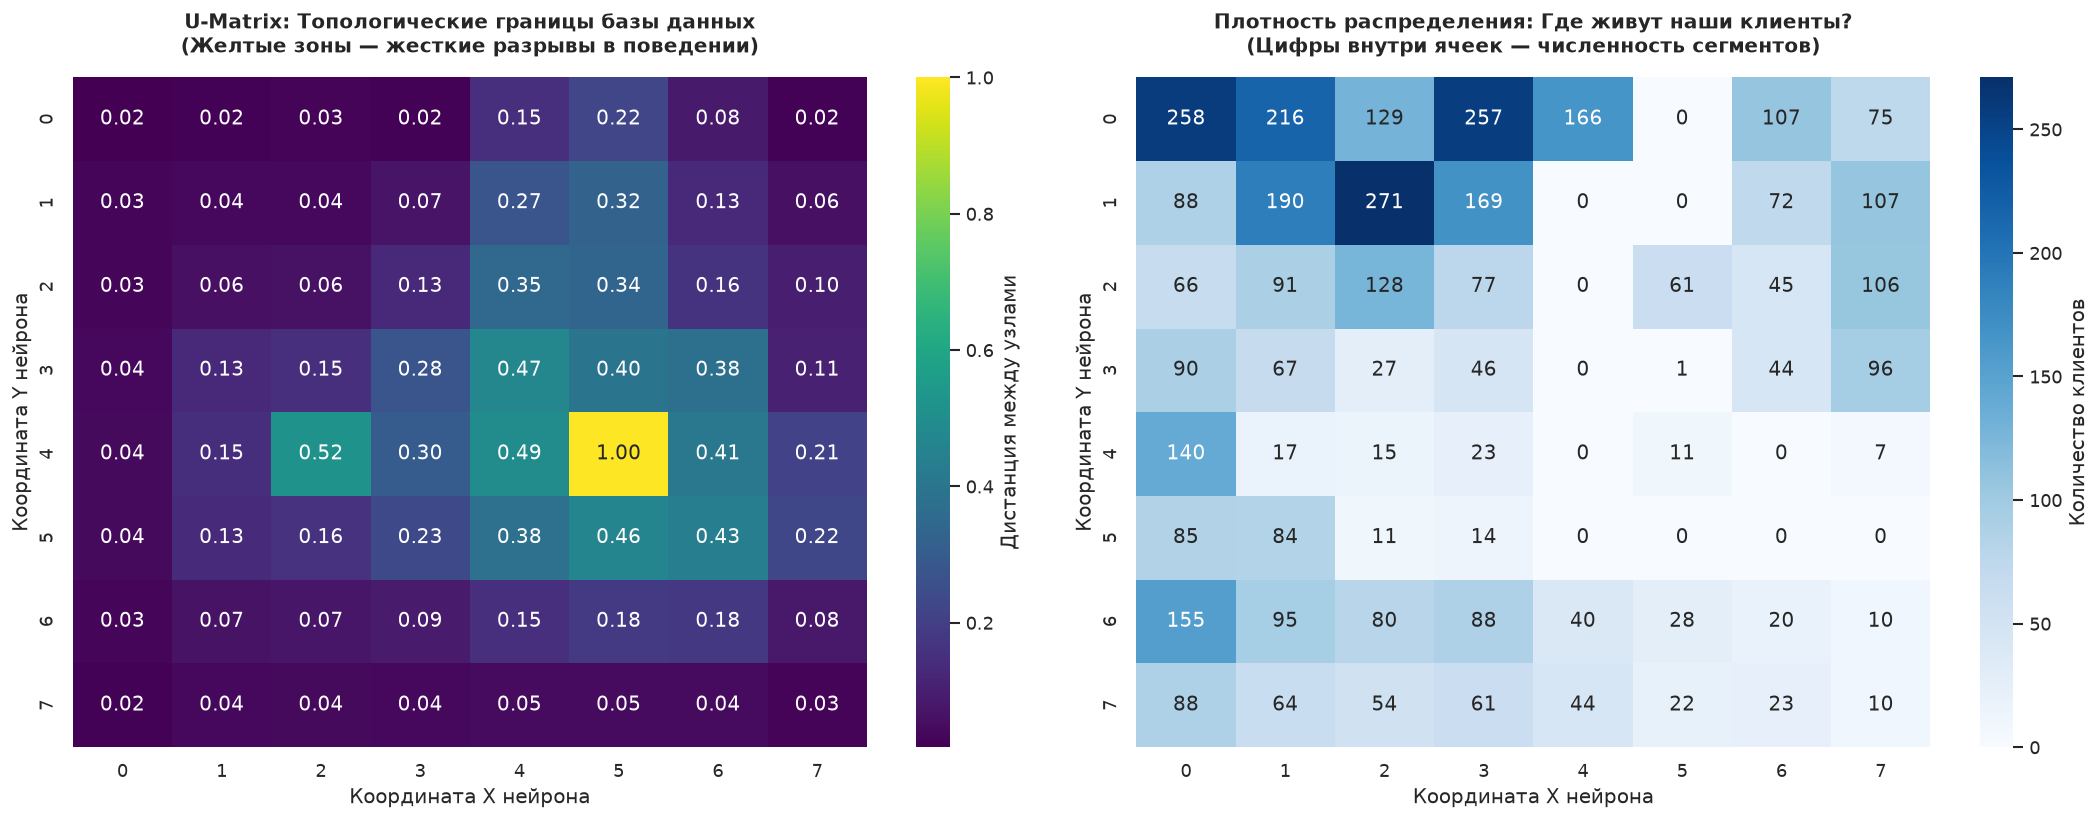

In [20]:
from minisom import MiniSom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Шаг 1: Инициализация и обучение нейросети MiniSom...")

# Задаем размерность сетки карты Кохонена (8х8 нейронов = 64 микро-сегмента)
map_size = 8

# ВАЖНО: input_len требует количество признаков (число колонок), поэтому берем shape[1]
som = MiniSom(
    x=map_size, 
    y=map_size, 
    input_len=X_scaled_df.shape[1], 
    sigma=1.2, 
    learning_rate=0.5, 
    neighborhood_function='gaussian',
    random_seed=42
)

# Обучаем нейросеть
som.train_batch(X_scaled_df.values, num_iteration=1000, verbose=False)
print("✅ Нейросеть успешно обучена!")

print("⏳ Шаг 2: Маппинг клиентов и расчет матрицы расстояний (U-Matrix)...")
# Получаем карту топологических расстояний
u_matrix = som.distance_map()

# Определяем, в какой конкретно нейрон (ячейку) попадает каждый клиент
winner_coordinates = np.array([som.winner(x) for x in X_scaled_df.values])

# Считаем количество клиентов в каждой из 64 ячеек
counts_matrix = np.zeros((map_size, map_size))
for x, y in winner_coordinates:
    counts_matrix[x, y] += 1

print("⏳ Шаг 3: Генерация топографической карты потребительского поведения...")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

# График 1: U-Matrix (Используем стандартную надежную палитру 'viridis')
# Чем желтее/светлее ячейка, тем сильнее разрыв в поведении между соседями
sns.heatmap(u_matrix, cmap='viridis', ax=axes[0], annot=True, fmt=".2f", cbar_kws={'label': 'Дистанция между узлами'})
axes[0].set_title("U-Matrix: Топологические границы базы данных\n(Желтые зоны — жесткие разрывы в поведении)", fontsize=12, weight='bold', pad=15)
axes[0].set_xlabel("Координата X нейрона")
axes[0].set_ylabel("Координата Y нейрона")

# График 2: Плотность расселения клиентов по нейронам (Палитра 'Blues')
sns.heatmap(counts_matrix, cmap='Blues', ax=axes[1], annot=True, fmt=".0f", cbar_kws={'label': 'Количество клиентов'})
axes[1].set_title("Плотность распределения: Где живут наши клиенты?\n(Цифры внутри ячеек — численность сегментов)", fontsize=12, weight='bold', pad=15)
axes[1].set_xlabel("Координата X нейрона")
axes[1].set_ylabel("Координата Y нейрона")

plt.tight_layout()

# Сохраняем нейросетевую карту в отчеты
report_som_path = "../reports/som_kohonen_map.png"
plt.savefig(report_som_path, dpi=300)
print(f"🎉 Нейросетевая карта SOM успешно сохранена: {report_som_path}")

plt.show()


В качестве финальной валидации была обучена нейросеть MiniSom (Карта Кохонена 8x8) напрямую на пространстве поведенческих признаков. Результаты анализа плотности распределения и матрицы расстояний (U-Matrix) полностью подтвердили результаты алгоритма K-Means:

- Массовый сегмент "спящих" клиентов монолитно локализован в верхнем левом углу карты (нейроны с плотностью >250 клиентов), формируя однородное фиолетовое плато с минимальным расстоянием между узлами (0.02-0.04).

- Сегмент B2B-оптовиков ("китов") изолирован нейросетью в узле [3, 5] и окружен абсолютно пустыми нейронами.

- На матрице расстояний U-Matrix зафиксирован экстремальный топологический барьер в координатах [4, 5] со значением 1.00. 

Наличие этой "стены" математически доказывает качественный, непреодолимый разрыв в паттернах поведения между розничными потребителями и крупным оптом, что делает их совместное обслуживание в рамках единых маркетинговых кампаний неэффективным

### 16. Расчет комплексных метрик качества кластеризации
В данном разделе мы проводим расчет комплексных метрик качества кластеризации

In [21]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

print("⏳ Расчет комплексных метрик качества кластеризации...")

# Считаем все три метрики на основе X_scaled_df и наших меток labels_4
sil = silhouette_score(X_scaled_df, labels_4)
db_index = davies_bouldin_score(X_scaled_df, labels_4)
ch_index = calinski_harabasz_score(X_scaled_df, labels_4)

print("\n🎯 --- МАТЕМАТИЧЕСКАЯ ВЕРИФИКАЦИЯ МОДЕЛИ (4 КЛАСТЕРА) ---")
print(f"1. Silhouette Score (Силуэт)      [В идеале -> +1]: {sil:.4f}")
print(f"2. Davies-Bouldin Index (ДБ)     [В идеале ->  0]: {db_index:.4f}")
print(f"3. Calinski-Harabasz Index (КХ)   [В идеале -> max]: {ch_index:.1f}")
print("-" * 55)


⏳ Расчет комплексных метрик качества кластеризации...

🎯 --- МАТЕМАТИЧЕСКАЯ ВЕРИФИКАЦИЯ МОДЕЛИ (4 КЛАСТЕРА) ---
1. Silhouette Score (Силуэт)      [В идеале -> +1]: 0.7628
2. Davies-Bouldin Index (ДБ)     [В идеале ->  0]: 0.7143
3. Calinski-Harabasz Index (КХ)   [В идеале -> max]: 8602.7
-------------------------------------------------------


🔬 Глубокий анализ верификации модели (4 кластера)

Silhouette Score = 0.7628  
Что это значит: Коэффициент силуэта близок к единице. Это подтверждает, что в среднем каждый клиент находится в геометрическом центре именно своего сегмента и бесконечно далек от чужих групп. В ритейл-задачах любое значение силуэта выше 0.5 считается отличным, а 0.76 указывает на монолитную внутреннюю структуру кластеров.

Davies-Bouldin Index = 0.7143  
Что это значит: Индекс Дэвиса–Болдина стремится к нулю. Значение 0.71 математически доказывает, что внутрикластерный разброс (плотность «расселения» клиентов внутри серого или синего облака) значительно меньше, чем расстояния между центроидами самих кластеров. Наши сегменты получились компактными и хорошо изолированными друг от друга.

Calinski-Harabasz Index = 8,602.7  
Что это значит: Индекс Калински–Харабаша измеряет отношение межкластерной дисперсии к внутрикластерной. Значение в 8.6 тысяч единиц — это огромный показатель. Он сигнализирует о том, что разделение на глобальные «материки» (B2B оптовики, сезонные VIP и регулярная розница) выражено на порядки сильнее, чем случайный хаос и флуктуации трат клиентов внутри этих групп.
